In [1]:
using JLD2, Plots


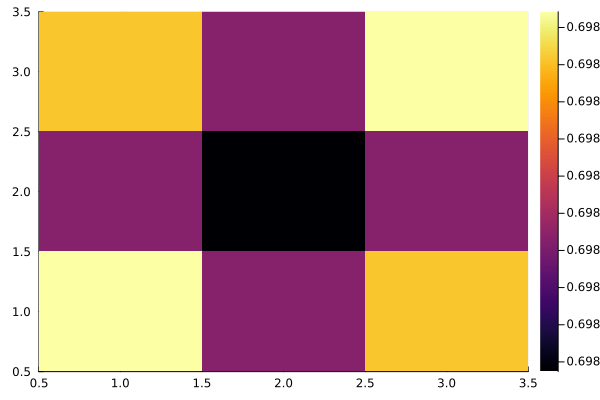

In [3]:
st2=load("try_nopotential_withint_randomgauge.jld2")
st2["energy"]
heatmap(imag.(st2["Flink"]))


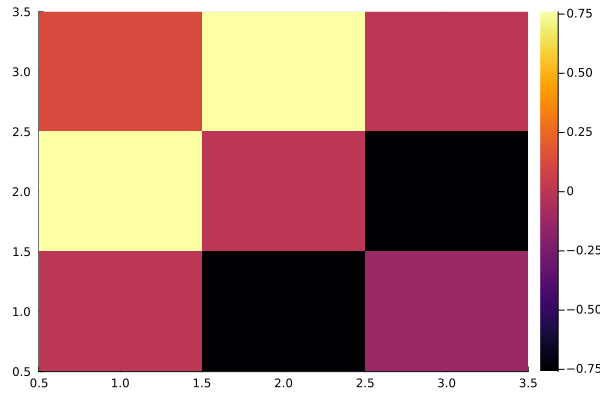

In [44]:
st4=load("try_noint.jld2")
st4["energy"]
heatmap(imag.(st4["Flink"]))

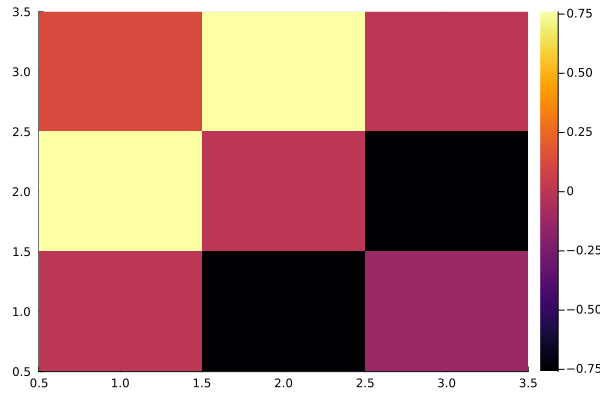

In [45]:
st3=load("try_noint_nogauge.jld2")
st3["energy"]
heatmap(imag.(st3["Flink"]))

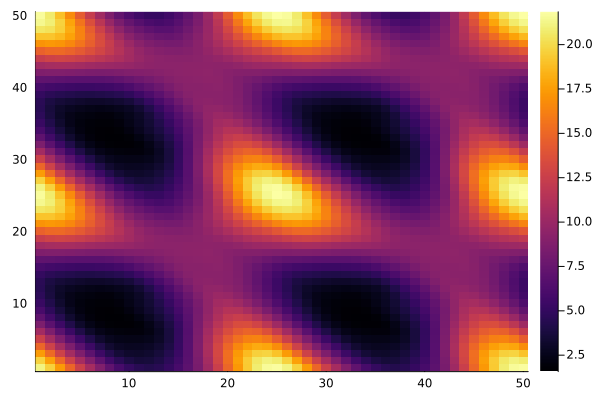

In [52]:
heatmap(st3["HFdensity"])

In [46]:
st3["HF_eigenvec"]

9-element Vector{Matrix{ComplexF64}}:
 [8.061697780291577e-6 - 1.5740157484868142e-5im 0.00013306838849811646 - 7.390838988130405e-5im … 0.10000346650364439 + 0.03419240387728067im -0.3850972215102625 - 0.13166935698060162im; -9.154815665843973e-5 - 3.236997253234196e-5im -8.4353404115924e-5 - 0.00022509023982403024im … -0.0021454340111754623 - 0.004091363583392924im 0.0065424009429582135 + 0.02076802303513916im; … ; -1.2922298022170916e-5 + 9.62387360844652e-5im -3.555009453963358e-5 - 0.00023773368214916895im … 0.0020402565045334973 - 0.004138432959901356im 0.012909503446435946 - 0.01753449490743106im; 1.768455622143814e-5 + 0.0im -0.00015221578798642446 - 0.0im … -0.105687339805185 - 0.0im -0.40698487635882846 - 0.0im]
 [7.557192838212297e-6 - 2.679898191986065e-5im 0.00011163175772766648 - 6.27451134076041e-5im … -3.971713782694493e-5 - 1.3679397037809503e-5im -5.2139848809571225e-9 - 1.8042450495054826e-9im; -0.00011104781244078471 - 2.5079951751939743e-5im -0.0001994703415955191 

In [47]:
scale=1.0
am=4*π/(√3*scale);
scale=1.0
b1=4*π/(√3*am)*[0,1]
b2=4*π/(√3*am)*[√3/2,-1/2]

Nq=3



T1=b1/(Nq)
T2=b2/(Nq)


allowedq=Vector{Int64}[]
    for ja in 0:Nq-1,jb in 0:Nq-1
        push!(allowedq,[ja,jb])
    end


    b1T=Int.(round.(inv([T1 T2])*b1))
    b2T=Int.(round.(inv([T1 T2])*b2))
    
    
    

    
    
    
    wave=Vector{Int64}[]
    cutoff=18
    cutoffstandard=3.01*scale
    for ja in -cutoff:cutoff, jb in -cutoff:cutoff
        gtest=ja*b1+jb*b2;
        if (gtest[1]^2+gtest[2]^2)<cutoffstandard^2
            push!(wave,ja*b1T+jb*b2T)
        end
    end
    dimension=length(wave)

37

In [49]:
xcoor=[]
ycoor=[]
zcoor=[]


for ja in 1:Nq^2, jb in 1:length(wave)
   wavevec=[T1 T2]*(allowedq[ja]+wave[jb])
   push!(xcoor,wavevec[1])
   push!(ycoor,wavevec[2])
   push!(zcoor,angle(st3["HF_eigenvec"][ja][jb,1]))

end

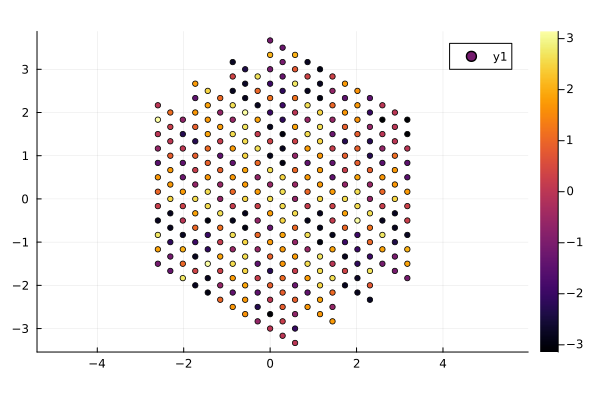

In [51]:
scatter(xcoor,ycoor,zcolor=zcoor,ms=3,aspect_ratio=:equal)